# Chapter 3: Statistical Experiments and Significance Testing

## Introduction

Statistical experiments and significance testing help determine whether observed differences between groups may be explained by random variation.

This chapter introduces A/B testing, hypothesis testing, resampling methods, p-values, t-tests, multiple testing, analysis of variance (ANOVA), chi-square tests, multi-arm bandit algorithms, and statistical power.

## Learning Objectives

* Understand A/B testing and control groups.
* Formulate null and alternative hypotheses.
* Perform permutation tests and t-tests.
* Interpret p-values and statistical significance.
* Understand Type I and Type II errors.
* Explore ANOVA and chi-square tests.
* Understand statistical power and sample size.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. A/B Testing

A/B testing is an experimental method used to compare two versions of a product, webpage, or process. Group A is commonly the control group, while Group B receives a change or treatment.

A control group provides a baseline for comparison. Random assignment helps reduce systematic differences between groups.

The result should be evaluated using both statistical evidence and practical relevance.


In [2]:
# Simulated website conversion data
group_a = np.array([12, 15, 14, 10, 13, 11, 16, 12, 14, 13])
group_b = np.array([16, 18, 15, 17, 14, 19, 16, 15, 18, 17])

print("Group A mean:", np.mean(group_a))
print("Group B mean:", np.mean(group_b))
print("Difference (B - A):", np.mean(group_b) - np.mean(group_a))

Group A mean: 13.0
Group B mean: 16.5
Difference (B - A): 3.5


## 2. Hypothesis Tests

A hypothesis test evaluates data against a specified statistical hypothesis.

* **Null hypothesis (H₀):** Usually states that there is no difference or effect.
* **Alternative hypothesis (H₁):** States that a difference or effect exists.

A one-sided test evaluates an effect in a specified direction. A two-sided test evaluates differences in either direction.

The test method should be chosen based on the research question and the data.


In [4]:
# Example: compare two independent groups
test_result = stats.ttest_ind(
    group_a,
    group_b,
    equal_var=False
)

print("t-statistic:", test_result.statistic)
print("p-value:", test_result.pvalue)

t-statistic: -4.58257569495584
p-value: 0.0002422931674064719


## 3. Resampling and Permutation Test

Resampling methods repeatedly draw or rearrange observations to evaluate the variability of a statistic.

A permutation test combines observations from two groups and randomly reallocates them under the null hypothesis of no group difference. The observed difference is then compared with the differences generated by these permutations.

This approach provides a data-based reference distribution for evaluating an observed effect.


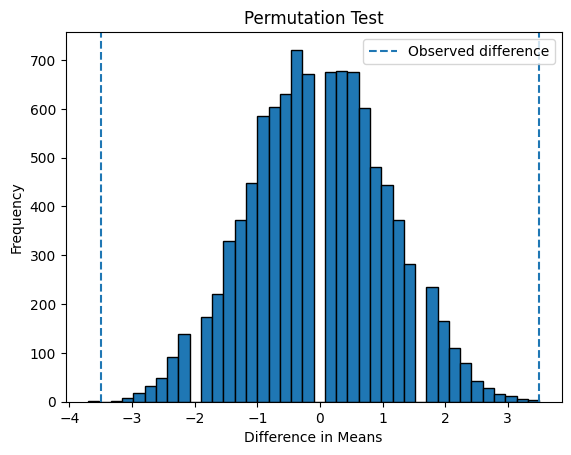

Observed difference: 3.5
Approximate two-sided p-value: 0.0004


In [5]:
observed_diff = np.mean(group_b) - np.mean(group_a)

combined = np.concatenate([group_a, group_b])
n_a = len(group_a)
permutation_diffs = []

for _ in range(10000):
    shuffled = np.random.permutation(combined)
    diff = np.mean(shuffled[n_a:]) - np.mean(shuffled[:n_a])
    permutation_diffs.append(diff)

permutation_diffs = np.array(permutation_diffs)

p_value = np.mean(
    np.abs(permutation_diffs) >= abs(observed_diff)
)

plt.hist(permutation_diffs, bins=40, edgecolor="black")
plt.axvline(observed_diff, linestyle="--", label="Observed difference")
plt.axvline(-observed_diff, linestyle="--")
plt.title("Permutation Test")
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print("Observed difference:", observed_diff)
print("Approximate two-sided p-value:", p_value)

## 4. Statistical Significance and p-Values

A p-value measures how likely it is to obtain a test statistic at least as extreme as the observed result, assuming the null hypothesis and the statistical model are correct.

The significance level, commonly denoted by α, is a threshold chosen before evaluating the result. A common choice is 0.05.

A small p-value provides evidence against the null hypothesis, but it does not measure the size or practical importance of an effect. A large p-value does not prove that the null hypothesis is true.


In [6]:
alpha = 0.05
p_value = test_result.pvalue

print("p-value:", p_value)
print("Significance level:", alpha)

if p_value < alpha:
    print("Statistically significant evidence against H0.")
else:
    print("Insufficient evidence to reject H0.")

p-value: 0.0002422931674064719
Significance level: 0.05
Statistically significant evidence against H0.


## 5. Type I and Type II Errors

A Type I error occurs when the null hypothesis is rejected even though it is true.

A Type II error occurs when the null hypothesis is not rejected even though it is false.

The significance level α controls the probability of a Type I error under the assumptions of the test. The probability of a Type II error is often denoted by β. Statistical power is \(1-\beta\).


In [7]:
alpha_values = [0.01, 0.05, 0.10]

for alpha_value in alpha_values:
    print(
        f"Alpha = {alpha_value:.2f}: "
        "the nominal Type I error threshold"
    )

Alpha = 0.01: the nominal Type I error threshold
Alpha = 0.05: the nominal Type I error threshold
Alpha = 0.10: the nominal Type I error threshold


## 6. t-Tests

A t-test is used to evaluate hypotheses about means. An independent two-sample t-test compares the means of two independent groups.

Welch's t-test does not assume that the two populations have equal variances. The test produces a t-statistic and a p-value, which can be interpreted in the context of the research question.


In [8]:
welch_result = stats.ttest_ind(
    group_a,
    group_b,
    equal_var=False
)

print("Welch t-statistic:", welch_result.statistic)
print("Two-sided p-value:", welch_result.pvalue)

Welch t-statistic: -4.58257569495584
Two-sided p-value: 0.0002422931674064719


## 7. Multiple Testing

Multiple testing occurs when several hypotheses are tested on the same dataset.

When many tests are conducted, the probability of obtaining at least one false positive can increase. Multiple-comparison procedures, such as the Bonferroni correction, can help control this problem.


In [9]:
p_values = np.array([0.01, 0.03, 0.04, 0.20, 0.60])

alpha = 0.05
number_of_tests = len(p_values)
bonferroni_threshold = alpha / number_of_tests

print("Bonferroni threshold:", bonferroni_threshold)
print("Original p-values:", p_values)
print("Significant after correction:", p_values < bonferroni_threshold)

Bonferroni threshold: 0.01
Original p-values: [0.01 0.03 0.04 0.2  0.6 ]
Significant after correction: [False False False False False]


## 8. Degrees of Freedom

Degrees of freedom describe the amount of independent information available for estimating a statistical quantity.

For a one-sample t-test, the degrees of freedom are typically \(n-1\), where n is the sample size. Degrees of freedom affect the shape of the t-distribution and other statistical reference distributions.


In [10]:
sample = np.array([10, 12, 13, 15, 16, 14, 11, 17])

df = len(sample) - 1

print("Sample size:", len(sample))
print("Degrees of freedom:", df)
print("t critical value (95% two-sided):", stats.t.ppf(0.975, df))

Sample size: 8
Degrees of freedom: 7
t critical value (95% two-sided): 2.3646242515927844


## 9. Analysis of Variance (ANOVA)

Analysis of variance (ANOVA) compares the means of three or more groups.

The F-statistic compares variation between groups with variation within groups. A sufficiently large F-statistic may provide evidence that not all population means are equal.

A significant ANOVA result does not identify which particular groups differ; additional comparisons may be required.


In [11]:
group_c = np.array([20, 22, 19, 21, 23, 20, 22, 21])

anova_result = stats.f_oneway(group_a, group_b, group_c)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

F-statistic: 55.12873754152824
p-value: 6.834931378119332e-10


## 10. Chi-Square Test

The chi-square test of independence evaluates whether two categorical variables are associated.

The test compares observed counts in a contingency table with expected counts under the assumption of independence. The result should be interpreted with attention to sample size and expected cell counts.


In [12]:
contingency_table = np.array([
    [30, 20],
    [15, 35]
])

chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected counts:\n", expected)

Chi-square statistic: 7.919191919191919
p-value: 0.004891311452359333
Degrees of freedom: 1
Expected counts:
 [[22.5 27.5]
 [22.5 27.5]]


## 11. Multi-Arm Bandit Algorithm

A multi-arm bandit algorithm is an approach for allocating trials among multiple alternatives while balancing exploration and exploitation.

Exploration gathers information about alternatives whose performance is uncertain. Exploitation allocates more trials to alternatives that currently appear to perform well.

These algorithms can be used in sequential experiments, such as comparing multiple webpage versions.


In [17]:
# 12. Power and Sample Size

import numpy as np
from statsmodels.stats.power import TTestIndPower

# Define parameters
effect_size = 0.5
alpha = 0.05
desired_power = 0.80

# Create power analysis object
analysis = TTestIndPower()

# Calculate required sample size
sample_size = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=desired_power,
    ratio=1.0,
    alternative="two-sided"
)

# Display the result
print("Effect size:", effect_size)
print("Significance level (alpha):", alpha)
print("Desired statistical power:", desired_power)
print("Estimated sample size per group:", int(np.ceil(sample_size)))
print("Total estimated sample size:", 2 * int(np.ceil(sample_size)))

Effect size: 0.5
Significance level (alpha): 0.05
Desired statistical power: 0.8
Estimated sample size per group: 64
Total estimated sample size: 128


## 12. Power and Sample Size

Statistical power is the probability that a test rejects the null hypothesis when a specified alternative is true.

Power depends on factors such as sample size, effect size, variability, and significance level. Larger samples can improve the ability to detect a real effect, although the required sample size depends on the study design and assumptions.

Sample-size planning helps researchers determine how many observations are needed for a meaningful comparison.


In [19]:
# 12. Power and Sample Size

import numpy as np
from statsmodels.stats.power import TTestIndPower

# Define parameters
effect_size = 0.5
alpha = 0.05
desired_power = 0.80

# Initialize power analysis
analysis = TTestIndPower()

# Calculate sample size
sample_size = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=desired_power,
    ratio=1.0,
    alternative="two-sided"
)

# Display results
print("Effect size:", effect_size)
print("Significance level (alpha):", alpha)
print("Desired power:", desired_power)
print("Sample size per group:", int(np.ceil(sample_size)))
print("Total sample size:", 2 * int(np.ceil(sample_size)))

Effect size: 0.5
Significance level (alpha): 0.05
Desired power: 0.8
Sample size per group: 64
Total sample size: 128


## 13. Summary

This chapter introduced statistical experiments and significance testing.

Key concepts include A/B testing, control groups, hypothesis tests, resampling, permutation tests, p-values, significance levels, Type I and Type II errors, t-tests, multiple testing, degrees of freedom, ANOVA, chi-square tests, multi-arm bandit algorithms, and statistical power.

These methods help analysts assess evidence, quantify uncertainty, and design experiments. Statistical significance should be considered alongside effect size, practical relevance, study design, and data quality.
